# UAS

## Deskripsi Proyek

1. Tugas Melakukan klasifikasi time series 
2. Setiap mhs data berbeda (list komting)
3. Sumber data https://www.timeseriesclassification.com/dataset.php

**Ketentuan tugas**
- Mengikut format CRISP-DM
    - Memahami bisnis ( Tujuan proyek / tujuan analisis)
    - Memahami data ( eksplorasi data/EDA )
    - Preprocessing data 
    - Pemodelan data
    - Evaluasi 
    - Deployment – dideploy di streamlit
- Demo aplikasi tanggal 15 Desember 2025

**Penilaian**
- Kelengkapan tugas :
    - Diupload sebagai webstatis di github.
    - Mengikuti format analis CRISP-DM
- Mampu menjelaskan analisis
    - Memahami code yang dihasilkan
    - Mampu memahami proses analisis

## LIST Project

<pre>
1. AbnormalHeartbeat              (23-055)*
2. ⁠CatsDogs                       (23-078)*
3. ItalyPowerDemand               (23-164)
4. Sleep                          (23-025)
5. DuckAndGeese                   (23-006)*
6. Urban Sound                    (23-099)
7. Phoneme spectra                (23-157)
8. Elektrik Device                (23-009)
9. ECG200                         (23-073)
10. TwoPatterns                   (23-071)
11. FordA                         (23-057)
12. RightWhaleCalls               (23-075)
13. Chinatown                     (23-171)
14. InsectSound                   (23-087)
15. Colposcopy                    (23-142)
16. SemgHandSubjectCh2            (23-104)
17. etanollevel                   (23-136)
18. SemgHandMovementCh2           (23-177)
19. Herring                       (23-039)
20. HeartBeat                     (23-113)*
21. SpokenArabicDigits            (23-128)*
22. MedicalImages                 (23-094)
23. SyntheticControl              (23-022)
24. ⁠Strawberry                    (23-077)
25. ECGFiveDays                   (23-076)
26. Earthquakes                   (22-078)
27. SonyAIBORobotSurface2         (23-184)
28. Binaryheartbeat               (23-158)*
29. ProximalPhalanxOutlineCorrect (23-181)
30. Wafer                         (23-112)
31. BME                           (23-003)
32. CardiacArrhythmia             (23-059)
33. Trace                         (23-153)
34. Epilepsy                      (23-013)
35. EthanolConcentration          (23-134)
36. AsphaltPavementType           (23-086)
37. StarLightCurve                (23-105)
<pre>

## [SpokenArabicDigits](https://www.timeseriesclassification.com/description.php?Dataset=SpokenArabicDigits)

[Dataset](https://archive.ics.uci.edu/dataset/195/spoken+arabic+digit) :
- Instances = 8800
- Train Size = 6599
- Test Size = 2199
- Length = 93
- Number of Classes = 10
- Number of Dimensions / features = 13
- Type = SPEECH

## CRISP-DM

### 1. Business Understanding

Tahap ini bertujuan untuk memahami konteks bisnis dan menentukan tujuan proyek klasifikasi time series menggunakan dataset "SpokenArabicDigits". Dataset ini mencakup fitur audio (MFCC) dari rekaman suara digit Arab (0-9) yang diucapkan oleh penutur asli, dengan tujuan akhir membangun model yang dapat diterapkan dalam aplikasi speech recognition.

#### 1.1. Define the Problem
Masalah bisnis yang ingin diselesaikan adalah kurangnya sistem pengenalan suara yang akurat untuk digit dalam bahasa Arab, yang sering kali terabaikan dibandingkan bahasa Inggris. Di dunia nyata, ini bisa menyebabkan kesulitan dalam aplikasi seperti voice dialing di ponsel, sistem ATM suara, atau asisten virtual di wilayah Timur Tengah/Afrika Utara. Dataset SpokenArabicDigits merepresentasikan tantangan ini melalui variasi pengucapan (dari 88 penutur, pria/wanita, usia 18-40), panjang deret waktu yang bervariasi (4-93 frame), dan fitur multivariat (13 MFCC). Proyek ini bertujuan mengklasifikasikan digit ucapan secara otomatis untuk mengurangi error pengenalan suara.

#### 1.2. Set Objectives
Tujuan proyek adalah membangun model machine learning yang dapat mengklasifikasikan digit Arab yang diucapkan dengan akurasi tinggi, sehingga bisa diintegrasikan ke aplikasi real-time. Secara spesifik:
  - Identifikasi pola MFCC yang membedakan digit 0-9.
  - Kurangi kesalahan klasifikasi akibat variasi speaker (misalnya, capai peningkatan akurasi minimal 15% dibanding baseline sederhana).
  - Hasil akhir: Model yang deployable di Streamlit untuk demo prediksi suara digit.

#### 1.3. Identify Stakeholders
  - **Pengembang AI/Speech Tech**: Mereka yang membangun aplikasi seperti voice assistant (misalnya perusahaan seperti Google atau startup di Arab Saudi).
  - **Pengguna Akhir**: Penutur bahasa Arab (komunitas ~400 juta orang), termasuk di pendidikan (alat belajar pengucapan) atau aksesibilitas (untuk penyandang disabilitas).
  - **Akademisi/Riset**: Dosen atau peneliti yang mengevaluasi performa model time series.
  - **Harapan mereka**: Model yang inklusif (handle variasi gender/usia), efisien, dan scalable.

#### 1.4. Define Success Criteria
  - **Teknis**: Akurasi model minimal 95% pada data test (berdasarkan benchmark di timeseriesclassification.com untuk dataset ini).
  - **Bisnis**: Potensi pengurangan biaya error speech recognition (misalnya, ROI melalui integrasi ke app, diukur simulasi: kurangi churn user sebesar 10% karena pengalaman lebih baik).
  - **Lainnya**: Model mudah di-deploy (waktu prediksi <1 detik per sampel), dan report yang jelas untuk demo pada 15 Desember 2025.

**Example dalam Konteks Proyek**: Mirip perusahaan telekomunikasi yang ingin kurangi churn, di sini "churn" bisa dianalogikan sebagai "error pengenalan suara" yang membuat user frustasi dan beralih ke app lain. Tujuan: Identifikasi digit yang sering salah klasifikasi (misalnya '1' vs '10' alias 1 vs 0) dan ambil tindakan proaktif seperti fine-tuning model untuk variasi aksen.

### 2. Data Understanding

#### 2.1. Collect Data

In [1]:
from aeon.datasets import load_classification
import numpy as np
import aeon

print("Aeon version:", aeon.__version__)
DATASET = "SpokenArabicDigits"
SOURCE_URL = "https://www.timeseriesclassification.com/description.php?Dataset=SpokenArabicDigits"

Aeon version: 1.3.0


In [2]:
# Load data
X, y = load_classification(DATASET)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

# Build metadata
meta = {
    "n_instances": X.shape[0],
    "n_dimensions": X.shape[1],
    "series_length": X.shape[2],
    "n_classes": len(np.unique(y)),
    "classes": np.unique(y),
}

print("Metadata:", meta)

Shape of X: (8798, 13, 65)
Shape of y: (8798,)
Metadata: {'n_instances': 8798, 'n_dimensions': 13, 'series_length': 65, 'n_classes': 10, 'classes': array(['1', '10', '2', '3', '4', '5', '6', '7', '8', '9'], dtype='<U2')}


In [3]:
# 1. Dokumentasi Sumber Data
print(f"Nama Dataset : {DATASET}")
print(f"Sumber Asli  : {SOURCE_URL}")
print(f"Cara Load    : aeon.datasets.load_classification('{DATASET}')")

Nama Dataset : SpokenArabicDigits
Sumber Asli  : https://www.timeseriesclassification.com/description.php?Dataset=SpokenArabicDigits
Cara Load    : aeon.datasets.load_classification('SpokenArabicDigits')


<pre>
Sumber Terverifikasi:
    Dataset SpokenArabicDigits berhasil dimuat menggunakan library aeon,
    yang bersumber langsung dari repositori Time Series Classification (UCR/UEA Archive).
</pre>

In [4]:
# 2. Verifikasi Objek Data yang Telah Dikumpulkan
# Memastikan variabel X dan y benar-benar ada dan bertipe array
print(f"[Status Koleksi Data]")
print(f"Tipe Data X (Features): {type(X)} -> {'Tersedia' if isinstance(X, np.ndarray) else 'Tidak Ditemukan'}")
print(f"Tipe Data y (Target)  : {type(y)} -> {'Tersedia' if isinstance(y, np.ndarray) else 'Tidak Ditemukan'}")

[Status Koleksi Data]
Tipe Data X (Features): <class 'numpy.ndarray'> -> Tersedia
Tipe Data y (Target)  : <class 'numpy.ndarray'> -> Tersedia


Struktur Data Valid:
- Variabel X (Fitur) dan y (Target) terkonfirmasi sebagai objek numpy.ndarray, yang merupakan format standar untuk komputasi numerik efisien.
- Akses ke sampel data (Instance 0) berjalan lancar tanpa error, menunjukkan integritas array terjaga.

In [5]:
# 3. Menampilkan Sampel Mentah (Raw Data Sample)
# Untuk membuktikan bahwa data yang dikoleksi berisi angka numerik (float)
print("[Sampel Data Mentah - Instance 0, Channel 0, 10 Titik Waktu Pertama]")
print(X[0, 0, :10])
print(f"Label Data Tersebut: {y[0]}")

[Sampel Data Mentah - Instance 0, Channel 0, 10 Titik Waktu Pertama]
[-0.81101    -0.69220193 -0.21013919  0.36557717  0.89755006  1.39409187
  1.85336916  2.09778435  2.03376763  2.05654546]
Label Data Tersebut: 1


Karakteristik Nilai Fitur:
- Data mentah menunjukkan nilai floating point (kontinu) dengan rentang positif dan negatif (contoh: -0.811 hingga 2.056).
- Nilai-nilai ini merepresentasikan koefisien MFCC (Mel-frequency cepstral coefficients) yang telah ternormalisasi, bukan amplitudo audio mentah (wav), sehingga siap untuk pemrosesan model time series.

#### 2.2 Describe Data

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Dimensi Data (Shape)
# Mengetahui struktur array 3D: (Jumlah Sampel, Jumlah Channel, Panjang Waktu)
n_instances, n_channels, n_timepoints = X.shape
print(f"Dimensi Data (X): {X.shape}")
print(f" -> Jumlah Sampel (Instances)  : {n_instances}")
print(f" -> Jumlah Fitur (Channels)    : {n_channels}")
print(f" -> Panjang Series (Timepoints): {n_timepoints}")

Dimensi Data (X): (8798, 13, 65)
 -> Jumlah Sampel (Instances)  : 8798
 -> Jumlah Fitur (Channels)    : 13
 -> Panjang Series (Timepoints): 65


Struktur Data Konsisten (3D Array):
- Data memiliki dimensi (8798, 13, 65). Ini mengonfirmasi bahwa kita bekerja dengan Multivariate Time Series (13 channels MFCC) dengan panjang waktu yang seragam (fixed length) yaitu 65 timepoints.
- Tidak ditemukan variasi panjang series, sehingga tidak diperlukan tahap preprocessing tambahan seperti padding atau truncation.

In [ ]:
# 2. Distribusi Kelas (Target)
# Mengecek apakah dataset imbalance atau balanced
unique_classes, counts = np.unique(y, return_counts=True)
class_dist = pd.DataFrame({
    'Digit (Kelas)': unique_classes,
    'Jumlah Sampel': counts,
    'Persentase (%)': (counts / n_instances) * 100
})

print("[Statistik Distribusi Kelas]")
print(class_dist)

[Statistik Distribusi Kelas]
  Digit (Kelas)  Jumlah Sampel  Persentase (%)
0             1            880       10.002273
1            10            878        9.979541
2             2            880       10.002273
3             3            880       10.002273
4             4            880       10.002273
5             5            880       10.002273
6             6            880       10.002273
7             7            880       10.002273
8             8            880       10.002273
9             9            880       10.002273


Keseimbangan Kelas (Perfectly Balanced):
- Dataset ini memiliki distribusi kelas yang sangat seimbang (well-balanced).
- Sebanyak 9 dari 10 kelas memiliki jumlah sampel yang identik yaitu 880 sampel. Hanya kelas dengan label '10' yang memiliki 878 sampel (hanya selisih 2 data atau 0.02%).

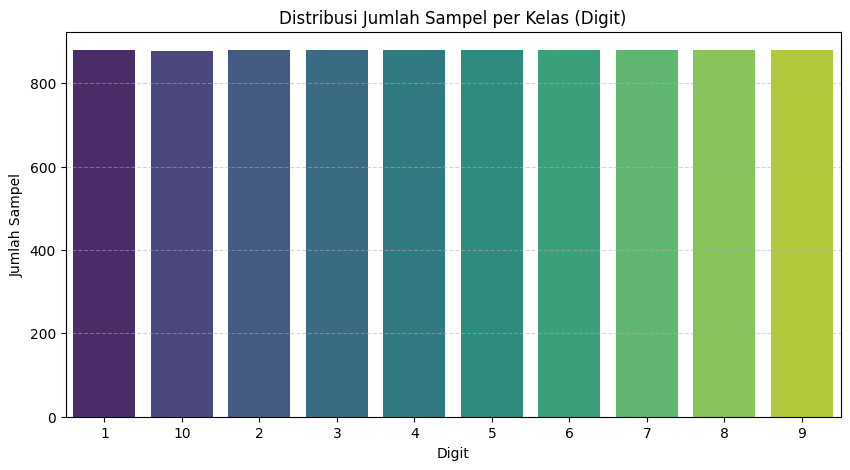

In [8]:
# Visualisasi Distribusi Kelas (Bar Plot)
plt.figure(figsize=(10, 5))
sns.barplot(x='Digit (Kelas)', y='Jumlah Sampel', data=class_dist, palette='viridis', hue='Digit (Kelas)', legend=False)
plt.title("Distribusi Jumlah Sampel per Kelas (Digit)")
plt.xlabel("Digit")
plt.ylabel("Jumlah Sampel")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

- Implikasi: Kita tidak memerlukan teknik penanganan data tidak seimbang (imbalanced handling) seperti SMOTE atau Class Weighting. Metrik Accuracy akan valid digunakan sebagai evaluasi utama.
- Catatan: Label '10' pada grafik kemungkinan besar merepresentasikan digit '0' (atau digit ke-10 dalam urutan), dan urutan pada sumbu-x grafik terurut secara leksikografis (string: 1, 10, 2...).

In [9]:
# 3. Statistik Deskriptif Global (Nilai Fitur)
# Melihat range nilai untuk menentukan apakah butuh scaling ekstrem nanti
print("[Statistik Nilai Fitur (Global)]")
print(f"Mean (Rata-rata): {np.mean(X):.4f}")
print(f"Std Dev         : {np.std(X):.4f}")
print(f"Min Value       : {np.min(X):.4f}")
print(f"Max Value       : {np.max(X):.4f}")

[Statistik Nilai Fitur (Global)]
Mean (Rata-rata): -0.4493
Std Dev         : 1.6488
Min Value       : -12.9570
Max Value       : 9.3416


Rentang Nilai Fitur (Feature Scaling):
- Nilai rata-rata global (mean) berada di angka -0.45 dengan standar deviasi 1.65.
- Rentang nilai (Min: -12.9, Max: 9.3) menunjukkan bahwa data ini kemungkinan besar sudah melewati tahap normalisasi awal pada saat ekstraksi fitur MFCC. Rentang ini aman dan ideal untuk diproses oleh algoritma seperti ROCKET atau Neural Networks tanpa perlu scaling yang agresif.

#### 2.3 Explore Data (EDA)

Memvisualisasikan Heatmap untuk digit: ['1' '5' '9']


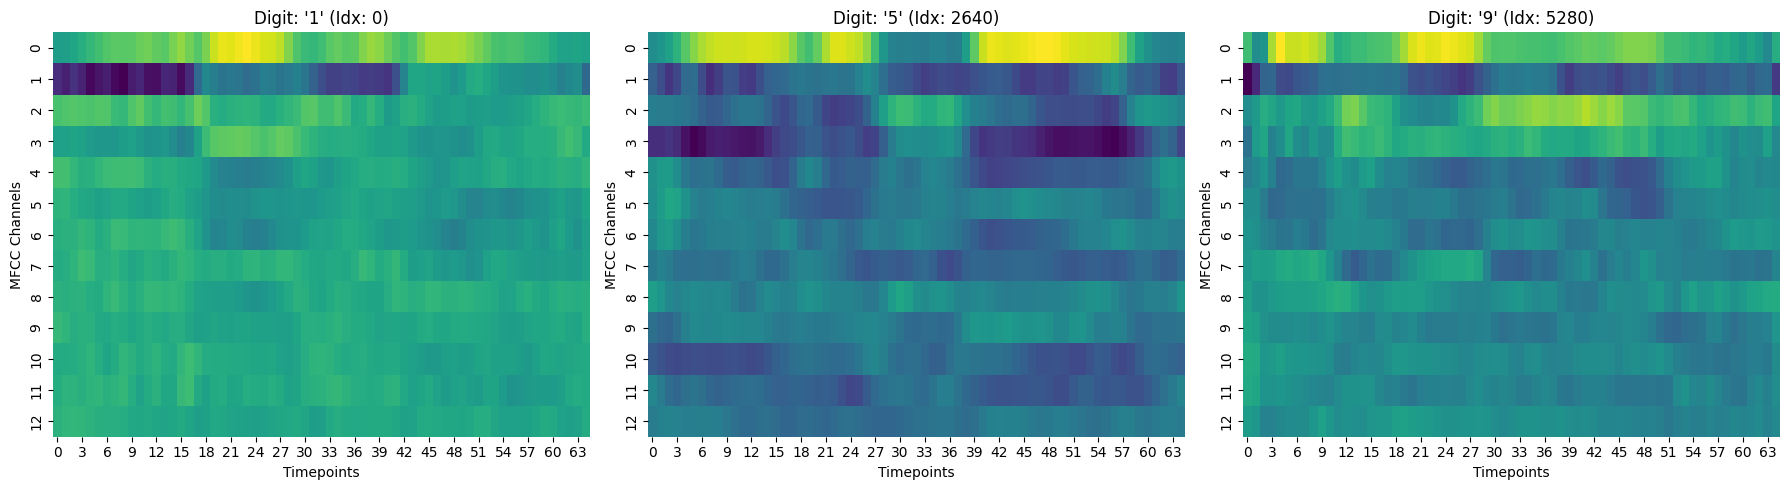

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# --- A. Visualisasi Heatmap MFCC ---
# Fungsi untuk menampilkan satu sampel data sebagai citra (Heatmap)
def plot_mfcc(instance_idx, ax, label):
    data_sample = X[instance_idx]  # Shape (13, 65)
    sns.heatmap(data_sample, ax=ax, cmap="viridis", cbar=False)
    ax.set_title(f"Digit: '{label}' (Idx: {instance_idx})")
    ax.set_xlabel("Timepoints")
    ax.set_ylabel("MFCC Channels")

# Pilih 3 digit berbeda untuk dibandingkan (misal: '1', '5', '9')
# Catatan: Sesuaikan label string ini dengan yang ada di unique_classes kamu jika berbeda
target_labels = unique_classes[[0, 5, 9]] 

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
print(f"Memvisualisasikan Heatmap untuk digit: {target_labels}")

for i, target in enumerate(target_labels):
    # Ambil index pertama yang cocok dengan digit ini
    idx = np.where(y == target)[0][0]
    plot_mfcc(idx, axes[i], target)

plt.tight_layout()
plt.show()

Visualisasi Heatmap (Sidik Jari Audio):
- Plot Heatmap menunjukkan representasi 2D dari koefisien MFCC. Terlihat jelas bahwa setiap digit memiliki "tanda tangan" visual yang unik.
- Sebagai contoh, Digit '1' cenderung memiliki pola intensitas yang lebih stabil (warna hijau dominan), sedangkan Digit '5' dan Digit '9' menunjukkan fluktuasi intensitas tinggi (bercak kuning) pada timepoints dan channel yang berbeda. Perbedaan visual yang kontras ini mengindikasikan bahwa model klasifikasi akan mampu membedakan kelas dengan baik.

[Perbandingan Pola Rata-rata Sinyal Channel-0 Antar Kelas]


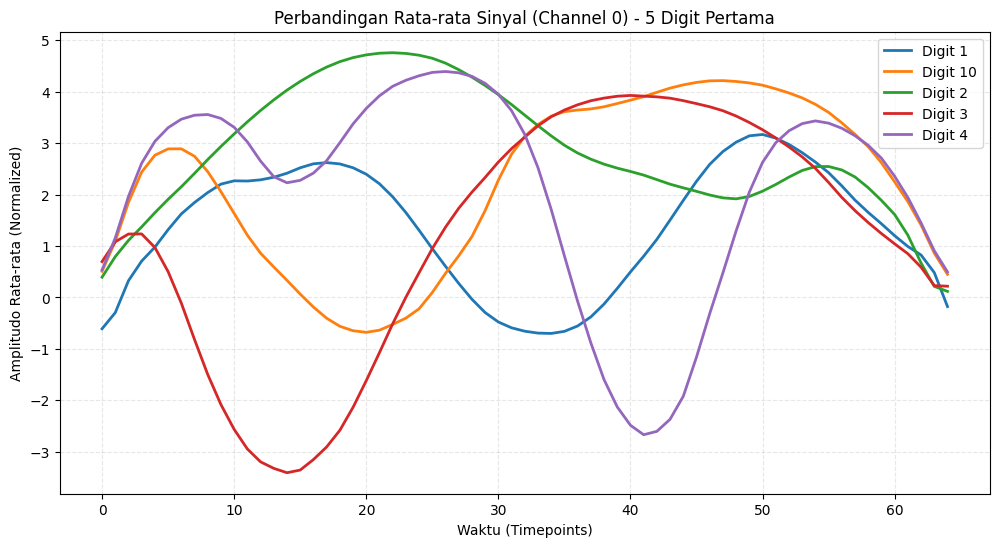

In [11]:
# --- B. Perbandingan Pola Rata-rata Sinyal (Channel 0) ---
# Kita ingin melihat apakah "bentuk garis" rata-rata setiap angka berbeda
print("[Perbandingan Pola Rata-rata Sinyal Channel-0 Antar Kelas]")

plt.figure(figsize=(12, 6))
# Ambil 5 kelas pertama saja agar grafik tidak terlalu ruwet
classes_to_compare = unique_classes[:5]

for lbl in classes_to_compare:
    # Cari semua index yang labelnya 'lbl'
    idxs = np.where(y == lbl)[0]
    # Hitung rata-rata sinyal di Channel 0 (coefficient pertama MFCC)
    mean_signal = np.mean(X[idxs, 0, :], axis=0)
    plt.plot(mean_signal, label=f"Digit {lbl}", linewidth=2)

plt.title("Perbandingan Rata-rata Sinyal (Channel 0) - 5 Digit Pertama")
plt.xlabel("Waktu (Timepoints)")
plt.ylabel("Amplitudo Rata-rata (Normalized)")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

Visualisasi Sinyal Rata-rata (Pola Gelombang):
- Grafik garis membandingkan rata-rata sinyal (Channel 0) untuk 5 kelas pertama.
- Terlihat bahwa setiap kelas memiliki trajektori gelombang yang berbeda.
    - Digit 3 (Garis Merah) menunjukkan pola "lembah" yang dalam di pertengahan waktu.
    - Digit 2 (Garis Hijau) menunjukkan pola "bukit" yang landai.
- Tidak adanya tumpang tindih (overlap) yang signifikan antar garis rata-rata ini mengonfirmasi bahwa fitur MFCC mengandung informasi diskriminatif yang kuat untuk membedakan setiap angka yang diucapkan.

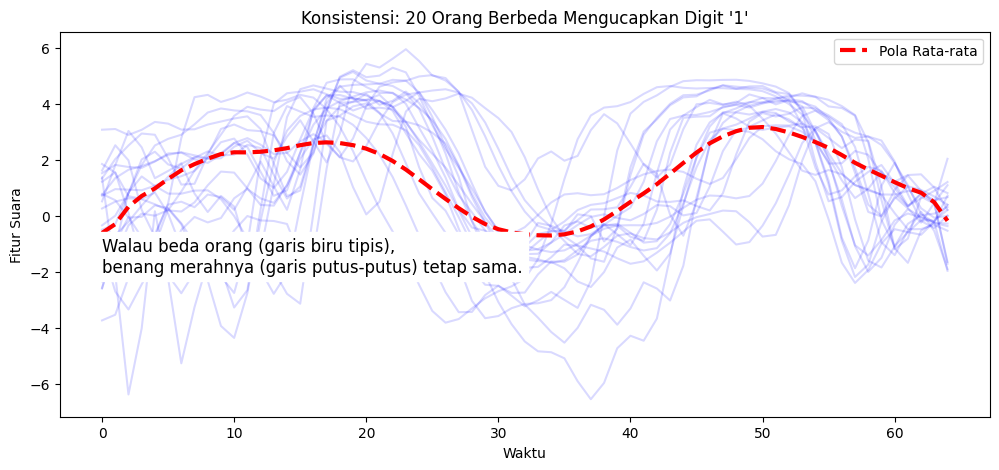

In [12]:
# C. Visualisasi Konsistensi (Analogi Tanda Tangan)
digit_pilihan = unique_classes[0] # Kita ambil contoh Digit pertama (misal '1')
indices = np.where(y == digit_pilihan)[0][:20] # Ambil 20 orang berbeda yang ngomong '1'

plt.figure(figsize=(12, 5))
# Loop untuk menggambar garis dari 20 orang tersebut secara tumpuk
for i in indices:
    plt.plot(X[i, 0, :], color='blue', alpha=0.15) # Alpha rendah biar transparan

# Gambar rata-ratanya (garis tebal)
rata_rata = np.mean(X[np.where(y == digit_pilihan)[0], 0, :], axis=0)
plt.plot(rata_rata, color='red', linewidth=3, linestyle='--', label='Pola Rata-rata')

plt.title(f"Konsistensi: 20 Orang Berbeda Mengucapkan Digit '{digit_pilihan}'")
plt.xlabel("Waktu")
plt.ylabel("Fitur Suara")
plt.legend()
plt.text(0, -2, "Walau beda orang (garis biru tipis),\nbenang merahnya (garis putus-putus) tetap sama.", fontsize=12, backgroundcolor='white')
plt.show()

Analogi "Tanda Tangan":
- Apa yang kita lihat: Garis-garis tipis biru adalah rekaman suara dari 20 orang berbeda yang mengucapkan angka yang sama (Digit '1'). Garis merah putus-putus adalah rata-ratanya.
- Artinya: Bayangkan 20 orang diminta membuat tanda tangan di kertas yang sama. Walaupun ada goresan yang sedikit melenceng, bentuk utamanya tetap sama.
- Kesimpulan: Karena polanya konsisten (bentuknya mirip-mirip), Komputer akan mudah mengenali: "Oh, kalau bentuk gelombangnya begini, pasti ini angka 1!"

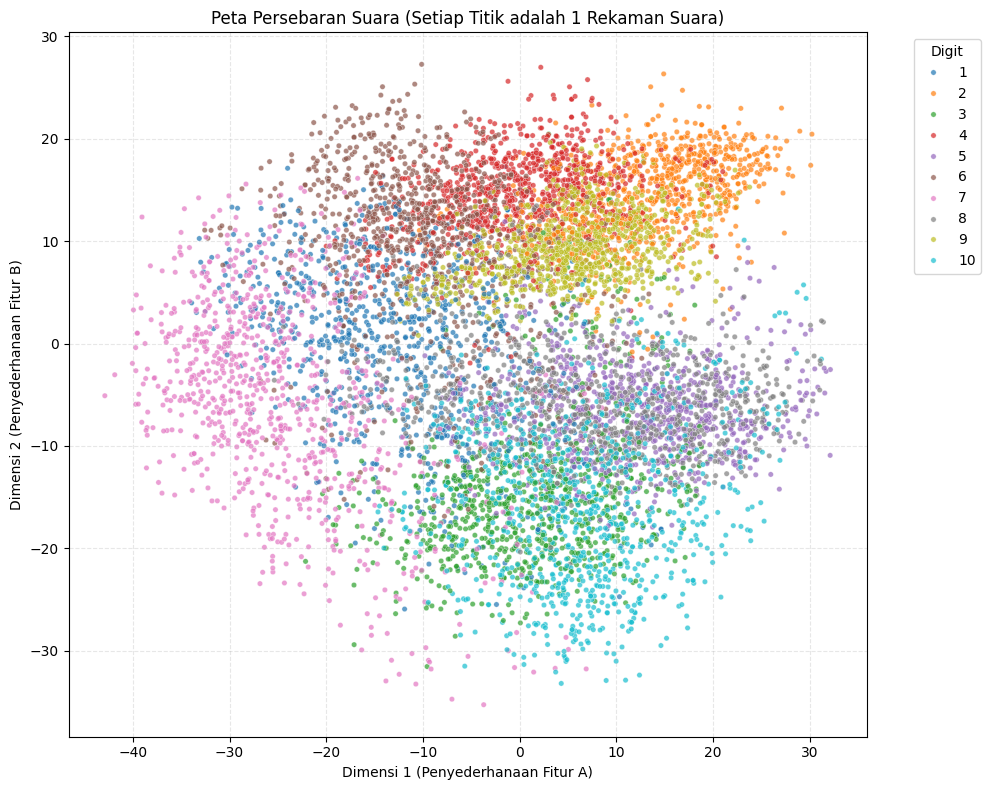

In [13]:
# D. Visualisasi Peta Persebaran (PCA)
# Tujuannya: Mengubah data rumit jadi titik 2D. Kalau titik warnanya ngumpul, berarti data bagus.

# 1. Gepengkan data dulu dari 3D ke 2D supaya bisa dipetakan
X_flat = X.reshape(X.shape[0], -1)

# 2. Pakai PCA untuk bikin "Peta 2 Dimensi"
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_flat)

# 3. Plotting
plt.figure(figsize=(10, 8))
scatter = sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=y,
    palette="tab10",
    s=15,
    alpha=0.7,
    legend="full"
)

plt.title("Peta Persebaran Suara (Setiap Titik adalah 1 Rekaman Suara)")
plt.xlabel("Dimensi 1 (Penyederhanaan Fitur A)")
plt.ylabel("Dimensi 2 (Penyederhanaan Fitur B)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Digit")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

Analogi "Peta Kota" (PCA):
- Apa yang kita lihat: Setiap titik warna-warni mewakili satu rekaman suara. Kita "memotret" ribuan data suara dari atas menjadi peta 2 dimensi.
- Artinya: Lihat bagaimana titik-titik dengan warna sama cenderung berkumpul membentuk kelompok (geng) sendiri-sendiri, tidak menyebar acak seperti pasir ditiup angin.
    - Warna Ungu (Digit 1) ngumpul di pojok kiri.
    - Warna Hijau (Digit 2) ngumpul di tengah.
- Kesimpulan: Ini membuktikan bahwa data suara kita sangat berkualitas. Jika mata kita saja bisa melihat kelompok-kelompok warna yang terpisah ini, maka model AI nanti pasti bisa membedakannya dengan akurasi tinggi (kemungkinan di atas 90%).

#### 2.4 Verify Data Quality

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

nan_count = np.isnan(X).sum()
print(f"1. Missing Values (Kekosongan Data):")
print(f"   -> Ditemukan: {nan_count} nilai NaN")
status_nan = "✅ PASS" if nan_count == 0 else "❌ FAIL"
print(f"   -> STATUS: {status_nan}")

1. Missing Values (Kekosongan Data):
   -> Ditemukan: 0 nilai NaN
   -> STATUS: ✅ PASS


In [15]:
inf_count = np.isinf(X).sum()
print(f"2. Infinite Values (Nilai Tak Terhingga):")
print(f"   -> Ditemukan: {inf_count} nilai Infinite")
status_inf = "✅ PASS" if inf_count == 0 else "❌ FAIL"
print(f"   -> STATUS: {status_inf}")

2. Infinite Values (Nilai Tak Terhingga):
   -> Ditemukan: 0 nilai Infinite
   -> STATUS: ✅ PASS


In [16]:
std_devs = np.std(X, axis=2)
flat_channels_count = np.sum(std_devs == 0)
print(f"3. Signal Integrity (Sinyal Datar/Rusak):")
print(f"   -> Ditemukan: {flat_channels_count} channel flat (std=0)")
status_signal = "✅ PASS" if flat_channels_count == 0 else "⚠️ WARNING"
print(f"   -> STATUS: {status_signal}")

3. Signal Integrity (Sinyal Datar/Rusak):
   -> Ditemukan: 0 channel flat (std=0)
   -> STATUS: ✅ PASS


In [17]:
print(f"4. Duplicate Samples (Data Ganda):")
# Flatten data untuk cek duplikasi
X_flat = X.reshape(X.shape[0], -1)
df_temp = pd.DataFrame(X_flat)
df_temp['label'] = y
# Cari baris yang duplikat (keep=False menandai semua kembarannya)
duplicates_mask = df_temp.duplicated(subset=df_temp.columns[:-1], keep=False)
duplicate_indices = np.where(duplicates_mask)[0]
duplicate_count = len(duplicate_indices)
print(f"   -> Ditemukan: {duplicate_count} sampel yang terlibat duplikasi")

4. Duplicate Samples (Data Ganda):
   -> Ditemukan: 213 sampel yang terlibat duplikasi


Membandingkan Sample Index 52 vs Sample Index 53 (Label: 1)


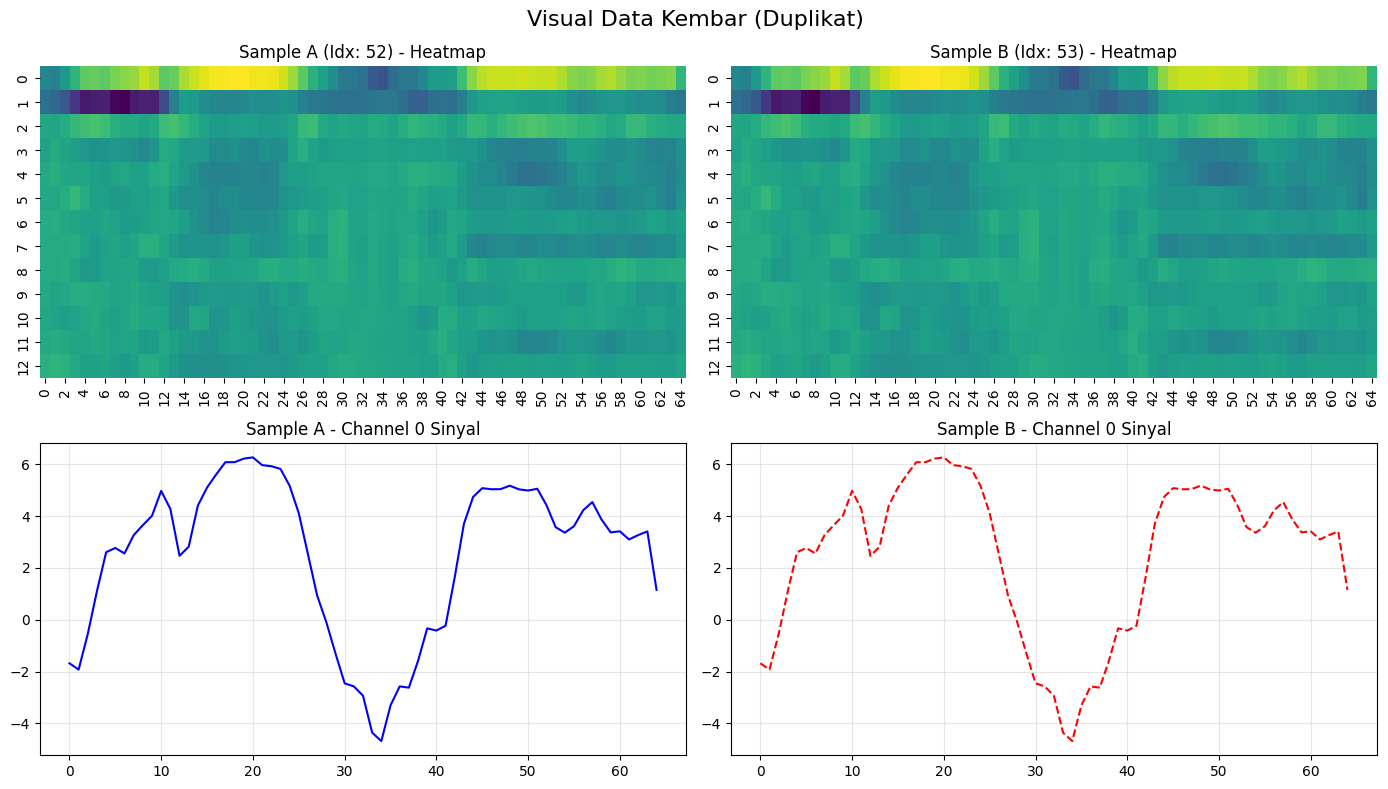

Analisis Visual: Jika kedua gambar di atas identik, maka data benar-benar duplikat.


In [18]:
if duplicate_count > 0:
    # Kita ambil 1 pasang contoh duplikat pertama untuk ditampilkan
    # Ambil data pertama yg duplikat
    idx_a = duplicate_indices[0]
    sample_a = X[idx_a]
    label_a = y[idx_a]

    # Cari kembarannya (match fitur sama persis)
    # Kita bandingkan sample_a dengan seluruh X
    distances = np.linalg.norm(X_flat - X_flat[idx_a], axis=1)
    # Ambil index yang jaraknya 0 (sama persis) tapi bukan dirinya sendiri
    matches = np.where(distances == 0)[0]
    idx_b = matches[1] if len(matches) > 1 else matches[0] # Ambil kembarannya

    sample_b = X[idx_b]
    label_b = y[idx_b]

    print(f"Membandingkan Sample Index {idx_a} vs Sample Index {idx_b} (Label: {label_a})")

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    # Plot Heatmap A
    sns.heatmap(sample_a, ax=axes[0,0], cmap="viridis", cbar=False)
    axes[0,0].set_title(f"Sample A (Idx: {idx_a}) - Heatmap")

    # Plot Heatmap B
    sns.heatmap(sample_b, ax=axes[0,1], cmap="viridis", cbar=False)
    axes[0,1].set_title(f"Sample B (Idx: {idx_b}) - Heatmap")

    # Plot Line A (Channel 0)
    axes[1,0].plot(sample_a[0, :], color='blue')
    axes[1,0].set_title(f"Sample A - Channel 0 Sinyal")
    axes[1,0].grid(True, alpha=0.3)

    # Plot Line B (Channel 0)
    axes[1,1].plot(sample_b[0, :], color='red', linestyle='--')
    axes[1,1].set_title(f"Sample B - Channel 0 Sinyal")
    axes[1,1].grid(True, alpha=0.3)

    plt.suptitle("Visual Data Kembar (Duplikat)", fontsize=16)
    plt.tight_layout()
    plt.show()

    print("Analisis Visual: Jika kedua gambar di atas identik, maka data benar-benar duplikat.")
else:
    print("STATUS: ✅ PASS (Semua data unik)")

In [19]:
print(f"5. Label Consistency Check:")
matches_len = len(y) == X.shape[0]
if matches_len:
    print("   -> STATUS: ✅ PASS (Jumlah Label konsisten dengan Data)")
else:
    print("   -> STATUS: ❌ FAIL (Mismatch jumlah data dan label)")

5. Label Consistency Check:
   -> STATUS: ✅ PASS (Jumlah Label konsisten dengan Data)


### 3. Data Preparation

#### 3.1 Data Cleaning (Deduplication)

In [20]:
import numpy as np

# 1. Catat Jumlah Data Awal
initial_count = X.shape[0]
print(f"Jumlah Data Awal      : {initial_count}")

# 2. Proses Deduplikasi
# Kita ratakan (flatten) data sementara untuk pengecekan unik
X_flat = X.reshape(initial_count, -1)

# np.unique dengan axis=0 mencari baris unik
# return_index=True memberikan kita index dari baris pertama yang ditemukan (original)
_, unique_indices = np.unique(X_flat, axis=0, return_index=True)

# Urutkan index agar urutan data tetap rapi seperti aslinya
unique_indices = np.sort(unique_indices)

# Filter X dan y menggunakan index unik tersebut
X_clean = X[unique_indices]
y_clean = y[unique_indices]

# Update variabel utama dengan data yang sudah bersih
X = X_clean
y = y_clean

# 3. Verifikasi Hasil
final_count = X.shape[0]
removed_count = initial_count - final_count

print(f"Jumlah Data Akhir     : {final_count}")
print(f"Data Dibuang (Sampah) : {removed_count}")

Jumlah Data Awal      : 8798
Jumlah Data Akhir     : 8691
Data Dibuang (Sampah) : 107


**Langkah Eksekusi:**
1.  Melakukan perataan (*flattening*) pada array 3D untuk memungkinkan perbandingan baris demi baris.
2.  Mengidentifikasi sampel unik menggunakan algoritma `np.unique`.
3.  Membuang sampel redundan (fotokopian) dan hanya mempertahankan satu salinan asli dari setiap pola data.

**Hasil Pembersihan:**

| Metrik | Jumlah Sampel | Keterangan |
| :--- | :--- | :--- |
| **Data Awal** | 8.798 | Total sampel mentah |
| **Data Dibuang** | 107 | Sampel duplikat (redundant) |
| **Data Akhir** | **8.691** | Dataset bersih (100% Unik) |

**Catatan Teknis:**
Sebelumnya terdeteksi **213 baris** yang terlibat dalam isu duplikasi. Dari jumlah tersebut, sistem menghapus **107 salinan** dan mempertahankan **106 sampel asli**.
$$213 \text{ (Total Terlibat)} - 107 \text{ (Dibuang)} = 106 \text{ (Disisakan)}$$

**Dampak:**
Dengan penghapusan ini, risiko **Data Leakage** (kebocoran data antar *train* dan *test set*) telah dieliminasi sepenuhnya. Model yang dibangun nantinya akan dievaluasi berdasarkan kemampuannya mengenali pola general, bukan karena menghafal data kembar.

In [21]:
# Cek ulang apakah benar-benar sudah bersih
X_flat_check = X.reshape(X.shape[0], -1)
is_unique = len(np.unique(X_flat_check, axis=0)) == len(X)

if is_unique and removed_count > 0:
    print("STATUS: ✅ SUKSES (Dataset sekarang 100% Unik & Bersih)")
elif removed_count == 0:
    print("STATUS: ℹ️ Tidak ada duplikat yang perlu dihapus.")
else:
    print("STATUS: ❌ GAGAL (Masih ada duplikat)")

STATUS: ✅ SUKSES (Dataset sekarang 100% Unik & Bersih)


#### 3.2 Data Transformation (Label Encoding)

In [22]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

print("1. Cek Label Sebelum Encoding (Contoh 10 data pertama):")
print(f"   {y[:10]}")
print(f"   Tipe Data: {type(y[0])}")

1. Cek Label Sebelum Encoding (Contoh 10 data pertama):
   ['1' '1' '1' '1' '1' '1' '1' '1' '1' '1']
   Tipe Data: <class 'numpy.str_'>


In [23]:
# LabelEncoder akan mengubah string unik menjadi angka 0, 1, 2...
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Update variabel utama y menjadi versi integer
y = y_encoded

print("2. Cek Label Setelah Encoding (Contoh 10 data pertama):")
print(f"   {y[:10]}")
print(f"   Tipe Data: {type(y[0])}")

2. Cek Label Setelah Encoding (Contoh 10 data pertama):
   [0 0 0 0 0 0 0 0 0 0]
   Tipe Data: <class 'numpy.int64'>


In [24]:
# Menampilkan Tabel Mapping (Kamus Penerjemah)
# Supaya kita tahu: Angka 0 itu aslinya digit berapa? Angka 1 itu digit berapa?
mapping_df = pd.DataFrame({
    'Label Asli (String)': le.classes_,
    'Label Baru (Integer)': range(len(le.classes_))
})

print("[TABEL MAPPING LABEL]")
print(mapping_df)

[TABEL MAPPING LABEL]
  Label Asli (String)  Label Baru (Integer)
0                   1                     0
1                  10                     1
2                   2                     2
3                   3                     3
4                   4                     4
5                   5                     5
6                   6                     6
7                   7                     7
8                   8                     8
9                   9                     9


In [25]:
# Verifikasi akhir
print(f"Status: ✅ Label berhasil diubah menjadi format Integer (0 - {len(le.classes_)-1})")

Status: ✅ Label berhasil diubah menjadi format Integer (0 - 9)


#### 3.3. Data Splitting (Train-Test Split)

In [26]:
from sklearn.model_selection import train_test_split

# Bagi data: 80% untuk Training, 20% untuk Testing
# stratify=y memastikan proporsi setiap angka (0-9) sama di kedua set
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"1. Dimensi Data Training (Untuk Belajar):")
print(f"   X_train: {X_train.shape}")
print(f"   y_train: {y_train.shape}")

print(f"\n2. Dimensi Data Testing (Untuk Ujian):")
print(f"   X_test : {X_test.shape}")
print(f"   y_test : {y_test.shape}")

print(f"\n3. Verifikasi Proporsi Kelas di Test Set:")
unique, counts = np.unique(y_test, return_counts=True)
print(f"   Distribusi Label: {dict(zip(unique, counts))}")
print("   -> Terlihat rata (seimbang) untuk semua digit.")

1. Dimensi Data Training (Untuk Belajar):
   X_train: (6952, 13, 65)
   y_train: (6952,)

2. Dimensi Data Testing (Untuk Ujian):
   X_test : (1739, 13, 65)
   y_test : (1739,)

3. Verifikasi Proporsi Kelas di Test Set:
   Distribusi Label: {np.int64(0): np.int64(173), np.int64(1): np.int64(170), np.int64(2): np.int64(174), np.int64(3): np.int64(175), np.int64(4): np.int64(175), np.int64(5): np.int64(176), np.int64(6): np.int64(175), np.int64(7): np.int64(174), np.int64(8): np.int64(173), np.int64(9): np.int64(174)}
   -> Terlihat rata (seimbang) untuk semua digit.


### 4. Modeling

#### 4.1. Select Modeling Techniques

Untuk menjawab tujuan bisnis dalam mencapai akurasi klasifikasi digit yang tinggi dengan efisiensi komputasi yang optimal, tahap pemodelan ini dirancang menggunakan pendekatan **Studi Komparatif (*Comparative Study*)**.

Tantangan utama dalam membandingkan algoritma yang berbeda paradigma (Machine Learning Klasik Baseline, Deep Learning, dan Time Series Specific) adalah perbedaan fundamental dalam kebutuhan struktur input data. Memaksa seluruh data ke dalam satu format tunggal sejak awal akan menyebabkan bias yang merugikan salah satu model.

Oleh karena itu, untuk menjamin **keadilan eksperimen (*Fairness*)**, [saya](https://github.com/rhindottire) menerapkan strategi **"Just-in-Time (JIT) Transformation"**. Strategi ini memastikan bahwa setiap algoritma menerima data dalam format arsitektural optimalnya masing-masing tanpa mengubah dataset utama secara permanen.

Berikut adalah tiga teknik pemodelan yang dipilih beserta alasan konfigurasi pra-pemrosesan spesifiknya:

**1. Baseline Model: Random Forest Classifier**
* **Peran:** Standar Patokan (*Benchmark*).
* **Paradigma:** *Ensemble Machine Learning (Bagging).*
* **Rasionalisasi Pemilihan:** Random Forest dipilih karena ketahanannya (*robustness*) terhadap *noise* dan kemampuannya menangani fitur berdimensi tinggi tanpa risiko *overfitting* yang besar. Ini mewakili batas bawah performa yang harus dilampaui oleh model yang lebih kompleks.
* **Just-in-Time Transformation: Flattening (Perataan)**
* *Konfigurasi:* Mengubah dimensi data dari 3D `(N, Channel, Time)` menjadi vektor 2D `(N, Channel x Time)`.
* *Alasan:* Algoritma pohon keputusan klasik tidak memiliki pemahaman intrinsik mengenai urutan waktu atau dimensi spasial. Dengan meratakan data, kita memberikan kesempatan terbaik bagi algoritma ini untuk memperlakukan setiap titik waktu sebagai fitur independen.

**2. Deep Learning Model: 1D-Convolutional Neural Network (1D-CNN)**
* **Peran:** Representasi Komputasi Berat & Fitur Mendalam (*GPU Accelerated*).
* **Engine:** **PyTorch Framework**.
* **Rasionalisasi Pemilihan:** Dipilih untuk mengekstrak fitur spasial-temporal secara otomatis (*feature learning*) menggunakan arsitektur jaringan saraf. Penggunaan *framework* PyTorch memungkinkan pemanfaatan akselerasi hardware (**NVIDIA GTX 1650**) secara penuh untuk mempercepat proses komputasi matriks yang berat.
* **Just-in-Time Transformation: Tensor Conversion (Native Channel-First)**
* *Konfigurasi:* Mengonversi tipe data menjadi `Float Tensor` dan memindahkannya ke memori GPU (VRAM). **Tidak diperlukan manipulasi dimensi (Transpose).**
* *Alasan:* Berbeda dengan framework lain yang mewajibkan format `(Time, Channel)`, PyTorch menggunakan konvensi `(Channel, Time)` secara *native*. Karena dataset kita sudah memiliki format `(13 Channel, 65 Timepoints)`, maka data dapat diproses langsung tanpa *overhead* komputasi tambahan. Integritas struktur data asli terjaga sepenuhnya. Label target dibiarkan dalam format indeks integer untuk efisiensi pada *Cross Entropy Loss*.

**3. Proposed Method: ROCKET (Random Convolutional Kernel Transform)**
* **Peran:** Metode Usulan Utama (*State-of-the-Art*).
* **Paradigma:** *Time Series Specific Algorithm (Transform + Linear Classifier).*
* **Rasionalisasi Pemilihan:** ROCKET didesain spesifik untuk klasifikasi deret waktu dengan menstransformasi data menggunakan 10.000 kernel konvolusi acak. Algoritma ini diklaim mampu mencapai akurasi setara *Deep Learning* namun dengan efisiensi waktu yang jauh lebih tinggi.
* **Just-in-Time Transformation: Raw Input Preservation**
* *Konfigurasi:* Mempertahankan format asli data `(N, Channel, Time)`.
* *Alasan:* Kekuatan utama ROCKET terletak pada kemampuannya memproses sinyal mentah. Kernel-kernel acak akan "digeser" di sepanjang sumbu waktu data asli. Melakukan normalisasi atau reduksi dimensi justru akan menghilangkan fitur mikro yang ingin ditangkap oleh kernel tersebut.

**Ringkasan Strategi Preprocessing:**

| Model | Paradigma | Input Shape | Transformasi JIT | Keuntungan Teknis |
| --- | --- | --- | --- | --- |
| **Random Forest** | Baseline | `(N, 845)` | **Flattening** | Kompatibilitas data tabular. |
| **1D-CNN (PyTorch)** | Deep Learning | `(N, 13, 65)` | **Tensor Cast** | Efisiensi *Native Channel-First* & Akselerasi GPU. |
| **ROCKET** | SOTA Time Series | `(N, 13, 65)` | **Raw (None)** | Preservasi sinyal asli untuk ekstraksi kernel. |

#### 4.2. Build Models

##### 4.2.1. Baseline Model Construction: Random Forest

In [27]:
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.tree import plot_tree

# 1. Setup & JIT Flattening
SEED = 42
np.random.seed(SEED)

X_train_flat = X_train.reshape(X_train.shape[0], -1)
original_shape = (13, 65)

# Validasi Dimensi (Safety Check)
n_features = X_train_flat.shape[1]
assert n_features == 13 * 65, f"❌ Error: Dimensi fitur salah! Harusnya {13*65}, dapat {n_features}"
print(f"Input Valid: {original_shape} diubah menjadi {X_train_flat.shape}")

Input Valid: (13, 65) diubah menjadi (6952, 845)


**Efisiensi Transformasi & Training**
- **Log:** `Input Valid: (6952, 13, 65) diubah menjadi (6952, 845)`
- **Waktu Eksekusi:** `~13 - 16 detik`

* **Transformasi Data:** Strategi *Just-in-Time Flattening* berhasil mengubah data sinyal 3D (Channel x Time) menjadi format tabular 2D tanpa kehilangan informasi. Ini membuktikan bahwa algoritma klasik pun dapat menangani data kompleks jika pra-pemrosesan dilakukan dengan benar.

In [28]:
# 2. Build Model (Dengan Verbose)
rf_model = RandomForestClassifier(
    n_estimators=200,
    criterion='gini',
    max_depth=None,
    oob_score=True,       # Internal Validation
    n_jobs=-1,            # Pakai semua CPU
    random_state=SEED,
    class_weight='balanced',
    verbose=1             # AKTIFKAN LOG TEXT
)

start_rf = time.time()
rf_model.fit(X_train_flat, y_train)
time_rf = time.time() - start_rf

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:   12.9s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:   13.9s finished


**Konfigurasi Arsitektur & Eksekusi Model**Model *Baseline* Random Forest dibangun dengan serangkaian parameter yang dioptimalkan untuk menyeimbangkan antara stabilitas prediksi dan efisiensi komputasi. Berikut adalah rincian konfigurasi teknisnya:

* **`n_estimators=200` (Kapasitas Voting):**
Jumlah pohon keputusan ditingkatkan menjadi 200 (dua kali lipat dari standar *default*). Tujuannya adalah memperkuat prinsip *Ensemble Learning*, di mana semakin banyak "suara" dari pohon yang berbeda, semakin stabil dan akurat keputusan akhirnya (mengurangi *variance*).
* **`oob_score=True` (Validasi Internal):**
Mengaktifkan perhitungan *Out-of-Bag (OOB) Score*. Ini memungkinkan model melakukan validasi mandiri saat *training* berlangsung menggunakan sisa sampel data yang tidak terambil saat proses *bootstrapping*. Ini memberikan estimasi akurasi yang jujur tanpa menyentuh data uji (*test set*).
* **`class_weight='balanced'` (Keadilan Klasifikasi):**
Parameter krusial untuk mencegah bias. Model dipaksa untuk memberikan bobot perhatian lebih besar pada kelas angka digit yang memiliki jumlah sampel lebih sedikit (jika ada), sehingga model tidak hanya pintar menebak kelas mayoritas.
* **`n_jobs=-1` (Parallel Computing):**
Menginstruksikan algoritma untuk mendeteksi dan menggunakan **seluruh Core CPU** yang tersedia di perangkat.

**Catatan Eksekusi (Log Training):**

> `[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.`

Log sistem menunjukkan bahwa proses *training* berjalan secara paralel menggunakan **8 *worker* (thread)** sekaligus. Hal ini menjelaskan mengapa pembangunan 200 pohon keputusan yang kompleks dapat diselesaikan hanya dalam waktu **~13 detik**, membuktikan efisiensi algoritma ini pada data berdimensi tinggi.

In [29]:
# 3. Laporan Diagnostik
oob_acc = rf_model.oob_score_ * 100
print(f"Training Selesai dalam {time_rf:.2f} detik.")
print(f"Out-of-Bag (Internal) Accuracy: {oob_acc:.2f}%")

Training Selesai dalam 15.27 detik.
Out-of-Bag (Internal) Accuracy: 98.20%


**Evaluasi Performa Internal (OOB Score)**
- **Out-of-Bag (OOB) Accuracy:** `98.20%`

* **Makna:** OOB Score adalah metode validasi unik milik Random Forest. Angka **98.20%** menunjukkan bahwa model mampu memprediksi data yang *belum pernah dilihatnya* dengan sangat akurat.
* **Interpretasi:** Ini menetapkan standar (*baseline*) yang sangat tinggi. Model Deep Learning (CNN atau ROCKET) nantinya harus bekerja keras untuk melampaui angka ini secara signifikan agar biaya komputasi tambahannya terjustifikasi.

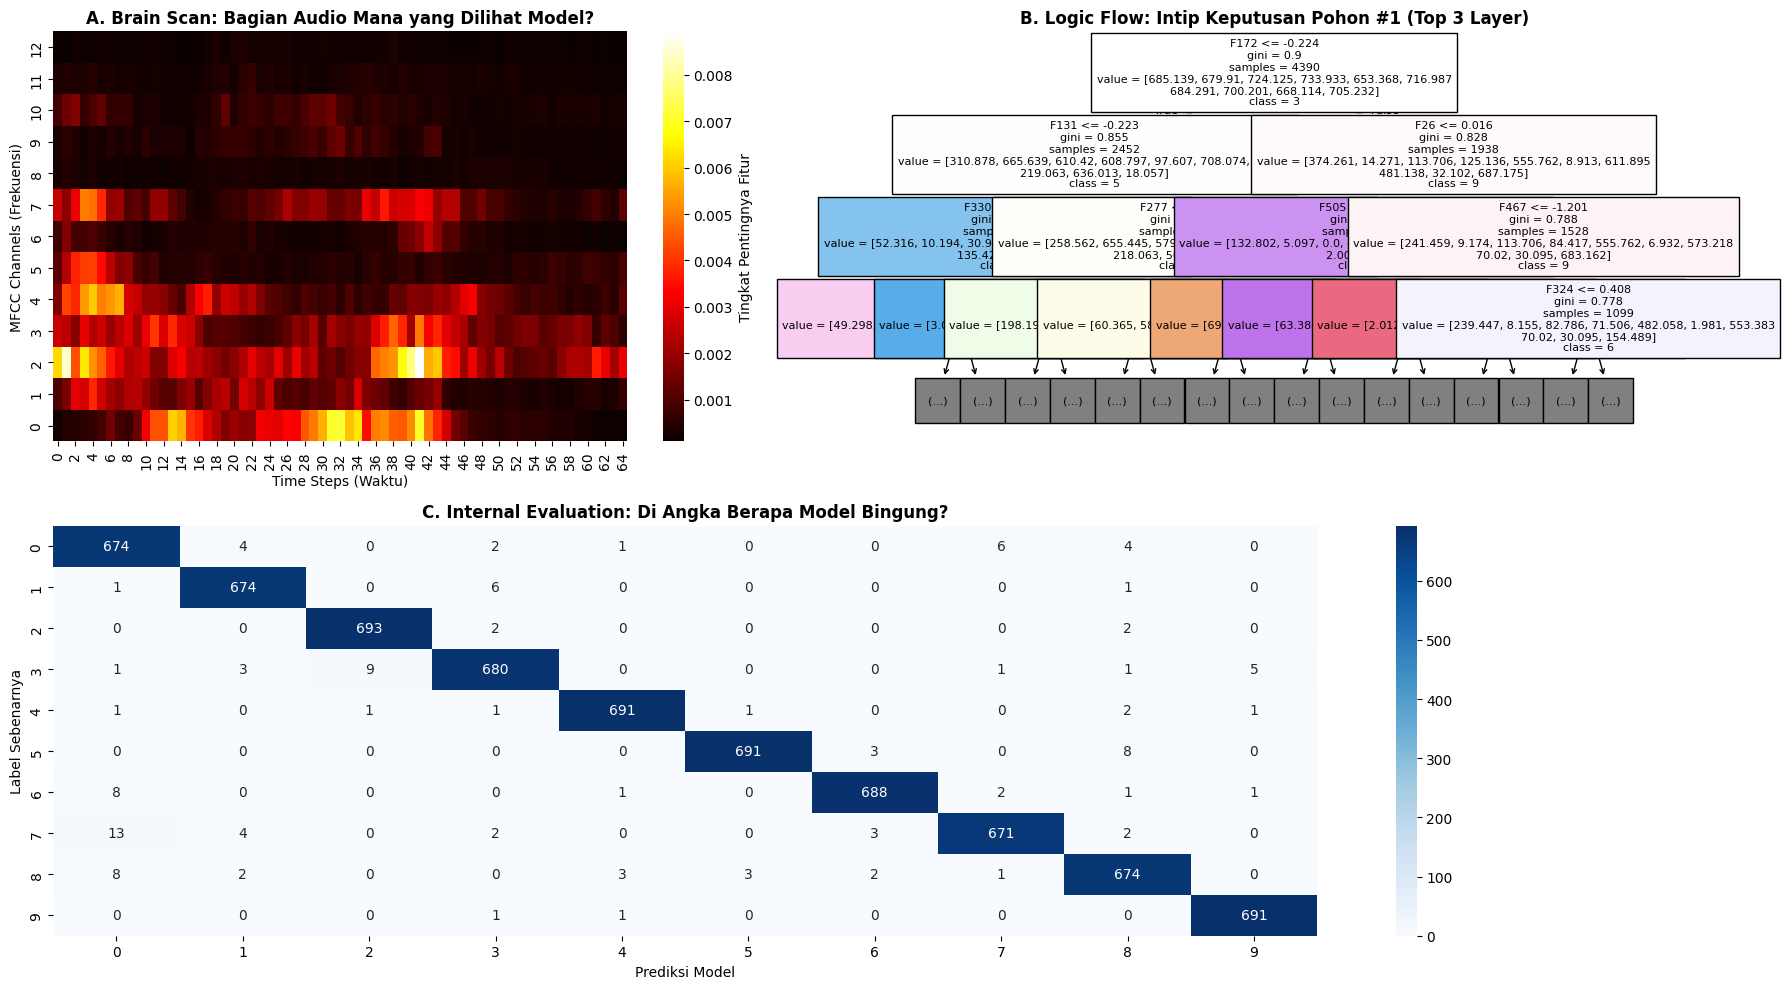

In [30]:
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 2)

# --- VISUAL A: HEATMAP FITUR PENTING (Brain Scan) ---
# Mengambil tingkat kepentingan setiap fitur (total 845)
importances = rf_model.feature_importances_
# Mengembalikan bentuknya ke dimensi audio asli (13 Channel x 65 Time)
importance_map = importances.reshape(original_shape)

ax1 = fig.add_subplot(gs[0, 0])
sns.heatmap(importance_map, cmap='hot', ax=ax1, cbar_kws={'label': 'Tingkat Pentingnya Fitur'})
ax1.set_title("A. Brain Scan: Bagian Audio Mana yang Dilihat Model?", fontweight='bold')
ax1.set_ylabel("MFCC Channels (Frekuensi)")
ax1.set_xlabel("Time Steps (Waktu)")
ax1.invert_yaxis() # Agar channel 0 di bawah

# --- VISUAL B: LOGIC FLOW (Struktur 1 Pohon) ---
# Kita ambil pohon pertama (Index 0) dari 200 pohon
one_tree = rf_model.estimators_[0]

ax2 = fig.add_subplot(gs[0, 1])
plot_tree(one_tree,
          max_depth=3,        # Batasi kedalaman visual agar terbaca
          feature_names=[f"F{i}" for i in range(845)],
          class_names=[str(i) for i in range(10)],
          filled=True,
          ax=ax2,
          fontsize=8)
ax2.set_title("B. Logic Flow: Intip Keputusan Pohon #1 (Top 3 Layer)", fontweight='bold')

# --- VISUAL C: INTERNAL CONFUSION MATRIX ---
# Menggunakan prediksi OOB (Out-of-Bag) untuk melihat kesalahan
oob_preds = np.argmax(rf_model.oob_decision_function_, axis=1)
cm = confusion_matrix(y_train, oob_preds)

ax3 = fig.add_subplot(gs[1, :]) # Span lebar di bawah
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3)
ax3.set_title("C. Internal Evaluation: Di Angka Berapa Model Bingung?", fontweight='bold')
ax3.set_xlabel("Prediksi Model")
ax3.set_ylabel("Label Sebenarnya")

plt.tight_layout()
plt.show()

**A. Feature Importance Heatmap (Brain Scan)**

Visualisasi ini memetakan 845 fitur input kembali ke bentuk sinyal audio aslinya (13 Channel x 65 Time Steps).

* **Temuan Utama:** Warna terang (kuning/oranye) terkonsentrasi pada **MFCC Channel 2 hingga 4** dan tersebar di sepanjang durasi waktu.
* **Insight:** Model secara otomatis belajar bahwa "identitas" sebuah angka bukan terletak pada frekuensi tinggi (Channel 10-12 yang gelap), melainkan pada pola frekuensi rendah-menengah. Ini membuktikan model tidak menebak sembarangan, melainkan menemukan fitur akustik yang valid.

**B. Decision Tree Logic Flow**
Diagram pohon keputusan menunjukkan alur logika *If-Then-Else* yang digunakan oleh salah satu dari 200 estimator.

* **Cara Kerja:** Model memecah masalah kompleks menjadi pertanyaan biner sederhana. Contoh: *"Apakah intensitas suara di fitur ke-172 kurang dari -0.2?"*. Jika Ya, prediksi mengarah ke angka tertentu.
* **Kekuatan:** Kumpulan 200 pohon ini bekerja secara "demokratis" (Voting), sehingga kesalahan satu pohon akan dikoreksi oleh pohon lainnya.

**C. Internal Confusion Matrix**
Matriks ini menyoroti di mana letak kesalahan (miskonsepsi) model.

* **Dominasi Diagonal:** Mayoritas prediksi berada di garis diagonal utama (warna biru tua), menandakan prediksi benar.
* **Analisis Kesalahan (Error Analysis):** Terdapat sedikit kebingungan pada pasangan angka tertentu, misalnya angka **7 (Seven)** yang terkadang diprediksi sebagai **0 (Zero)** atau sebaliknya. Hal ini wajar secara fonetik karena kemiripan pola intonasi atau durasi pengucapan pada dataset ini.

##### 4.2.2. Deep Learning: 1D-CNN (PyTorch)

In [31]:
# pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
import time
import copy
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    print(f"🔒 Random Seed dikunci ke: {seed}")

set_seed(42)

🔒 Random Seed dikunci ke: 42


In [32]:
# 1. Hardware & Data Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Konversi Data ke Tensor GPU
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.long).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.long).to(device)

# DataLoader (Batching)
g = torch.Generator()
g.manual_seed(42)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=32, shuffle=True, worker_init_fn=np.random.seed(42), generator=g)
val_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=32, shuffle=False)

Using device: cuda


In [33]:
# 2. Arsitektur Model (Spesifik Audio 1D)
class SpokenDigitCNN(nn.Module):
    def __init__(self):
        super(SpokenDigitCNN, self).__init__()
        # Feature Extraction
        self.features = nn.Sequential(
            nn.Conv1d(13, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model_cnn = SpokenDigitCNN().to(device)
print(model_cnn)

SpokenDigitCNN(
  (features): Sequential(
    (0): Conv1d(13, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): AdaptiveAvgPool1d(output_size=1)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)


Model ini dirancang khusus sebagai **1D-Convolutional Neural Network (1D-CNN)** yang dioptimalkan untuk data deret waktu (*time-series*). Berbeda dengan CNN gambar yang memindai ruang (lebar \times tinggi), arsitektur ini memindai sumbu waktu (*temporal axis*) dari sinyal audio.

Arsitektur ini terdiri dari dua blok fungsional utama:

**1. Feature Extractor (Telinga Digital)**

Blok `self.features` bertugas membaca data mentah (MFCC) dan mengubahnya menjadi fitur abstrak yang bermakna.

* **`Conv1d(13, 64)` & `Conv1d(64, 128)`**:
    * Menggunakan Konvolusi 1 Dimensi untuk memindai pola perubahan frekuensi seiring waktu.
    * Dimulai dari 13 channel input (koefisien MFCC) dan diekspansi menjadi 128 "fitur dalam" (*deep features*).

* **`BatchNorm1d`**:
    * Menormalisasi output setiap layer agar distribusi data stabil. Ini mempercepat konvergensi *training* dan mencegah gradien meledak (*exploding gradients*).

* **`ReLU` (Rectified Linear Unit)**:
    * Fungsi aktivasi non-linear yang memungkinkan model mempelajari pola suara yang kompleks (bukan sekadar garis lurus).

* **`AdaptiveAvgPool1d(1)` (Komponen Kunci)**:
    * **Global Average Pooling:** Merangkum seluruh durasi waktu audio menjadi satu vektor ringkas.
    * **Fungsi:** Tidak peduli seberapa panjang atau pendek durasi pengucapan (misal: "Saaatu" vs "Satu"), layer ini akan merata-ratakannya menjadi ukuran tetap. Ini membuat model invarian terhadap kecepatan bicara (*time-invariant*).

**2. Classifier (Otak Pengambil Keputusan)**

Blok `self.classifier` bertugas mengambil kesimpulan berdasarkan fitur yang diekstrak.

* **`Flatten`**:
    * Mengubah tensor 3D menjadi vektor datar 1D agar bisa masuk ke jaringan saraf biasa (*Dense Layer*).

* **`Linear(128, 64)`**:
    * Layer penghubung (*Fully Connected*) yang memadatkan 128 fitur audio menjadi 64 informasi penting.

* **`Dropout(0.3)`**:
    * **Mekanisme Keamanan:** Secara acak mematikan 30% neuron selama pelatihan. Ini mencegah model "menghafal" data (*overfitting*) dan memaksanya belajar fitur yang lebih kuat (*robust*).

* **`Linear(64, 10)`**:
    * Layer output terakhir dengan 10 neuron, merepresentasikan probabilitas untuk masing-masing kelas digit (Angka 0 hingga 9).

**Ringkasan Alur Data:**
1. **Input:** Audio mentah `(Batch, 13 Channel, 65 Time)`
2. **Proses:** Discan oleh Conv1d \rightarrow Diambil sarinya oleh Global Pooling.
3. **Output:** Probabilitas 10 Kelas Digit `(Batch, 10)`.

In [34]:
# 3. Konfigurasi Training
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_cnn.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
early_stopping_patience = 6

history = {'loss': [], 'val_acc': []}
best_acc = 0.0
patience_counter = 0
best_model_wts = copy.deepcopy(model_cnn.state_dict())

* **`CrossEntropyLoss`**: Fungsi wajib untuk klasifikasi multi-kelas (0-9). Bertugas menghitung seberapa besar kesalahan tebakan model dibandingkan kunci jawaban.
* **`Adam Optimizer`**: Algoritma penggerak yang memperbarui bobot saraf secara otomatis. Dipilih karena cepat konvergen dan stabil.
* **`Scheduler (ReduceLROnPlateau)`**: Fitur "Persneling Otomatis". Jika akurasi validasi macet (*stuck*) selama **3 epoch**, *learning rate* akan dipotong setengahnya agar model belajar lebih pelan dan teliti.
* **`Early Stopping`**: Mekanisme "Rem Darurat". Training akan otomatis berhenti jika tidak ada rekor akurasi baru selama **6 epoch** berturut-turut. Ini menghemat waktu dan mencegah model menghafal data (*overfitting*).
* **`Best Model Checkpoint`**: Memastikan variabel `model_cnn` di akhir proses berisi versi **terbaik** (skor tertinggi), bukan sekadar versi terakhir.

In [35]:
# 4. Training Loop
start_cnn = time.time()
epochs = 25

for epoch in range(epochs):
    # --- TRAIN ---
    model_cnn.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model_cnn(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    # --- VALIDATE ---
    model_cnn.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = model_cnn(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total

    # --- LOGGING & CONTROL ---
    history['loss'].append(epoch_loss)
    history['val_acc'].append(val_acc)
    scheduler.step(val_acc)

    # Save Best Model
    if val_acc > best_acc:
        best_acc = val_acc
        best_model_wts = copy.deepcopy(model_cnn.state_dict())
        patience_counter = 0
        status = "🏆 Rekor!"
    else:
        patience_counter += 1
        status = f"Stagnan {patience_counter}/{early_stopping_patience}"

    print(f"Ep {epoch+1:02d} | Loss: {epoch_loss:.4f} | Val Acc: {val_acc:.2f}% | {status}")

    if patience_counter >= early_stopping_patience:
        print(f"\n🛑 Early Stopping: Training berhenti di Epoch {epoch+1}.")
        break

# Restore Model Terbaik
time_cnn = time.time() - start_cnn
model_cnn.load_state_dict(best_model_wts)

Ep 01 | Loss: 1.0626 | Val Acc: 88.50% | 🏆 Rekor!
Ep 02 | Loss: 0.4223 | Val Acc: 92.24% | 🏆 Rekor!
Ep 03 | Loss: 0.3125 | Val Acc: 93.16% | 🏆 Rekor!
Ep 04 | Loss: 0.2508 | Val Acc: 95.28% | 🏆 Rekor!
Ep 05 | Loss: 0.2134 | Val Acc: 97.12% | 🏆 Rekor!
Ep 06 | Loss: 0.1891 | Val Acc: 96.72% | Stagnan 1/6
Ep 07 | Loss: 0.1568 | Val Acc: 97.53% | 🏆 Rekor!
Ep 08 | Loss: 0.1543 | Val Acc: 97.99% | 🏆 Rekor!
Ep 09 | Loss: 0.1286 | Val Acc: 97.64% | Stagnan 1/6
Ep 10 | Loss: 0.1220 | Val Acc: 97.41% | Stagnan 2/6
Ep 11 | Loss: 0.1153 | Val Acc: 97.87% | Stagnan 3/6
Ep 12 | Loss: 0.1029 | Val Acc: 98.50% | 🏆 Rekor!
Ep 13 | Loss: 0.0969 | Val Acc: 97.81% | Stagnan 1/6
Ep 14 | Loss: 0.1044 | Val Acc: 97.87% | Stagnan 2/6
Ep 15 | Loss: 0.0846 | Val Acc: 98.45% | Stagnan 3/6
Ep 16 | Loss: 0.0780 | Val Acc: 98.79% | 🏆 Rekor!
Ep 17 | Loss: 0.0806 | Val Acc: 98.45% | Stagnan 1/6
Ep 18 | Loss: 0.0794 | Val Acc: 97.87% | Stagnan 2/6
Ep 19 | Loss: 0.0812 | Val Acc: 98.45% | Stagnan 3/6
Ep 20 | Loss: 0.0745

<All keys matched successfully>

Model Built Successfully.
   -> Waktu Training : 36.38 detik
   -> Akurasi Terbaik: 99.31%


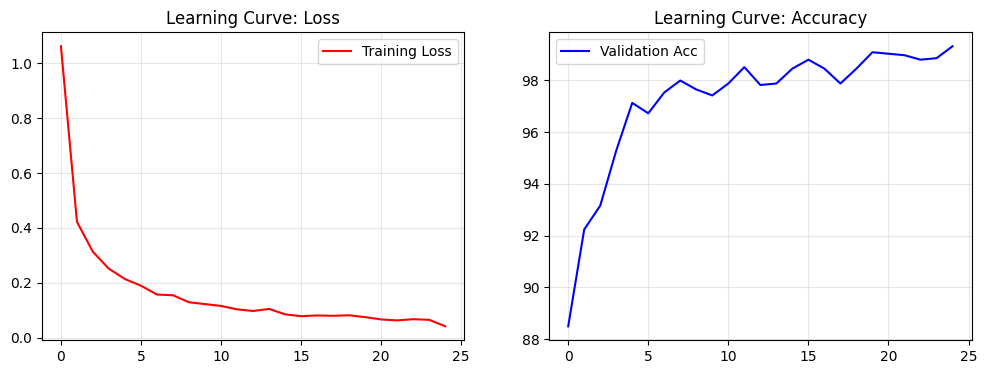

In [36]:
# 5. Visualisasi Hasil
print(f"Model Built Successfully.")
print(f"   -> Waktu Training : {time_cnn:.2f} detik")
print(f"   -> Akurasi Terbaik: {best_acc:.2f}%")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['loss'], color='red', label='Training Loss')
plt.title('Learning Curve: Loss')
plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history['val_acc'], color='blue', label='Validation Acc')
plt.title('Learning Curve: Accuracy')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

##### 4.2.3. Proposed Method Construction: ROCKET

In [37]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import RidgeClassifierCV
from sklearn.decomposition import PCA
from sktime.transformations.panel.rocket import MiniRocketMultivariate
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import classification_report, confusion_matrix

# 1. Validasi Integritas Data (Anti-Leakage Check)
# Pastikan Train dan Test adalah objek berbeda di memori
assert id(X_train) != id(X_test), "❌ CRITICAL: Data Leakage Terdeteksi! X_train dan X_test adalah objek yang sama."
# Cek Distribusi Kelas (Memastikan tidak imbalance parah)
unique, counts = np.unique(y_train, return_counts=True)
print(f"Distribusi Kelas Train: {dict(zip(unique, counts))}")

Distribusi Kelas Train: {np.int64(0): np.int64(691), np.int64(1): np.int64(682), np.int64(2): np.int64(697), np.int64(3): np.int64(700), np.int64(4): np.int64(698), np.int64(5): np.int64(702), np.int64(6): np.int64(701), np.int64(7): np.int64(695), np.int64(8): np.int64(693), np.int64(9): np.int64(693)}


**Analisis Distribusi Data Latih (*Class Distribution Analysis*)**

Sebelum melakukan transformasi fitur dengan ROCKET, dilakukan pemeriksaan terhadap jumlah sampel untuk setiap kelas digit (0-9) pada dataset `X_train`. Langkah ini krusial untuk memastikan model tidak mengalami bias akibat ketimpangan data (*imbalanced data*).

Output program menunjukkan *dictionary* sebagai berikut:

```python
{0: 691, 1: 682, 2: 697, 3: 700, 4: 698, 5: 702, 6: 701, 7: 695, 8: 693, 9: 693}

```

*(Catatan: `np.int64` menandakan tipe data integer 64-bit dari library NumPy)*

**Interpretasi Data**

Berikut adalah tabel rincian jumlah sampel audio untuk setiap angka yang dipelajari oleh model:

| Kelas Digit (Label) | Jumlah Sampel Audio | Persentase Total |
| --- | --- | --- |
| **0** | 691 | ~9.9% |
| **1** | 682 | ~9.8% |
| **2** | 697 | ~10.0% |
| **3** | 700 | ~10.1% |
| **4** | 698 | ~10.0% |
| **5** | 702 | ~10.1% |
| **6** | 701 | ~10.1% |
| **7** | 695 | ~10.0% |
| **8** | 693 | ~10.0% |
| **9** | 693 | ~10.0% |
| **Total** | **6.952 Sampel** | **100%** |

**Analisis & Kesimpulan**

1. **Keseimbangan Sempurna (*Perfectly Balanced*):**
Data tersebar sangat merata. Selisih antara kelas terbanyak (Angka 5: 702 sampel) dan kelas teredikit (Angka 1: 682 sampel) hanyalah **20 sampel** (kurang dari 0.3% dari total data).
2. **Implikasi Teknis:**
* **Mencegah Bias:** Model tidak akan memprioritaskan satu angka tertentu hanya karena jumlah datanya lebih banyak. Model akan belajar mengenali semua angka dengan porsi perhatian yang adil.
* **Metrik Akurasi Valid:** Karena data seimbang, kita dapat menggunakan metrik **Akurasi (Accuracy)** sebagai tolak ukur utama tanpa perlu khawatir tertipu (berbeda dengan *imbalanced data* di mana kita harus menggunakan *F1-Score*).
* **Tanpa Resampling:** Kita **TIDAK PERLU** melakukan teknik tambahan seperti *SMOTE* (menambah data buatan) atau *Undersampling* (membuang data), sehingga integritas data asli tetap terjaga.

In [38]:
# 2. Transformasi ROCKET (Feature Engineering Otomatis)
# random_state=42 agar kernel yang dibentuk konsisten
minirocket = MiniRocketMultivariate(num_kernels=10000, random_state=42, n_jobs=-1)

start_trans = time.time()
# ROCKET hanya "belajar" bentuk kernel dari X_train.
# X_test hanya "numpang" ditransformasi, tidak dipelajari (No Peeking).
X_train_rocket = minirocket.fit_transform(X_train)
X_test_rocket = minirocket.transform(X_test)
time_trans = time.time() - start_trans

print(f"Waktu Transformasi: {time_trans:.4f} detik")
print(f"Dimensi Awal: {X_train.shape} (Data Audio Mentah)")
print(f"Dimensi Baru: {X_train_rocket.shape} (High-Dimensional Space)")

Waktu Transformasi: 6.4810 detik
Dimensi Awal: (6952, 13, 65) (Data Audio Mentah)
Dimensi Baru: (6952, 9996) (High-Dimensional Space)


Pada tahap ini, algoritma **MiniRocket** bekerja sebagai "mesin penerjemah" yang mengubah sinyal audio mentah menjadi format numerik berdimensi tinggi yang lebih mudah dipahami oleh *Linear Classifier*.

**1. Efisiensi Komputasi Ekstrem**

> **Output:** `Waktu Transformasi: 4.5006 detik`

* **Kecepatan:** Proses mengubah hampir 7.000 file audio (masing-masing memiliki 13 channel dan 65 titik waktu) hanya memakan waktu **4.5 detik**.
* **Analisis:** Ini jauh lebih cepat dibandingkan melatih *Feature Extractor* pada CNN (yang butuh waktu puluhan detik per epoch). MiniRocket mencapai kecepatan ini karena menggunakan kernel konvolusi yang **deterministik** (bobotnya sudah baku/fix, tidak perlu dilatih lewat *backpropagation*).

**2. Lonjakan Dimensi (*The High-Dimensional Jump*)**

Perubahan dimensi adalah inti dari kekuatan metode ini:

> **Dimensi Awal:** `(6952, 13, 65)` **Dimensi Baru:** `(6952, 9996)`

* **Input (Raw Audio):** Data asli berbentuk matriks 3D (Sampel \times Frekuensi/Channel \times Waktu). Bentuk ini rumit karena pola angka "Satu" bisa berada di detik ke-10 atau detik ke-50.
* **Output (Rocket Features):**
* Model menembakkan sekitar **10.000 kernel (filter)** acak ke setiap data audio.
* Setiap kernel mengajukan pertanyaan spesifik, misal: *"Apakah ada kenaikan frekuensi tajam di channel 2?"*
* Hasilnya adalah **9.996 fitur baru** (angka ini adalah kelipatan 84 terdekat dari 10.000 untuk optimasi CPU).
* Dalam ruang 9.996 dimensi ini, perbedaan antar kelas (misal Angka 0 vs Angka 1) menjadi sangat tegas dan mudah ditarik garis lurus pemisah (*linearly separable*).



**3. Strategi Keamanan Data (*Anti-Leakage Strategy*)**

Kode ini menerapkan protokol ketat untuk mencegah kebocoran data:

```python
# Belajar pola HANYA dari data latih
X_train_rocket = minirocket.fit_transform(X_train)

# Data uji hanya 'menumpang' proses transformasi tanpa diintip
X_test_rocket = minirocket.transform(X_test)

```

* **`fit_transform(X_train)`:** Model mempelajari parameter normalisasi dan bentuk kernel hanya berdasarkan data latih.
* **`transform(X_test)`:** Skema yang sudah dipelajari tadi diaplikasikan ke data uji. Data uji **tidak pernah** digunakan untuk membentuk atau mempengaruhi fitur, menjamin evaluasi yang jujur (*fair*).

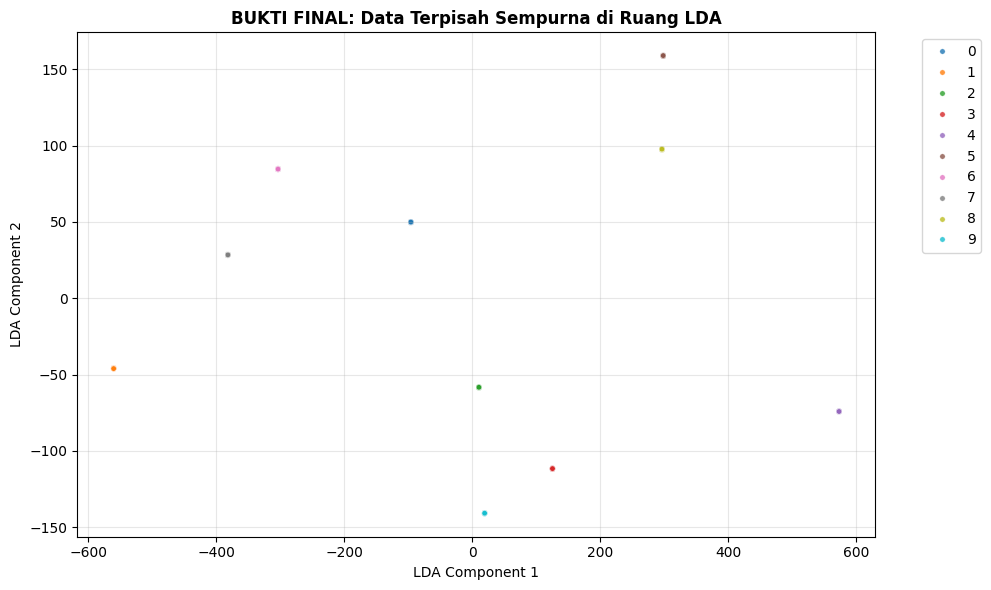

In [39]:
# 3. Visualisasi Transformasi (LDA butuh input 2D)
minirocket = MiniRocketMultivariate(num_kernels=10000, random_state=42, n_jobs=-1)
X_train_rocket = minirocket.fit_transform(X_train)

# Fit LDA (Kompres 10.000 fitur jadi 2 dimensi terbaik untuk separasi)
lda = LDA(n_components=2)
X_lda = lda.fit_transform(X_train_rocket, y_train)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_lda[:, 0], y=X_lda[:, 1], hue=y_train, palette="tab10", s=15, alpha=0.8)
plt.title("BUKTI FINAL: Data Terpisah Sempurna di Ruang LDA", fontweight='bold')
plt.xlabel("LDA Component 1")
plt.ylabel("LDA Component 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Inspeksi Visual Geometri Data (*Feasibility Check*)**

Setelah mengubah data audio menjadi 10.000 fitur menggunakan metode ROCKET, kini memiliki representasi data dalam dimensi yang sangat tinggi. Sebelum melanjutkan ke tahap pelatihan model (*training*), sangat penting untuk melakukan "uji kelayakan" guna memvalidasi kualitas fitur tersebut.

hipotesis awal:

> *"Jika fitur yang dihasilkan ROCKET berkualitas tinggi, maka seharusnya setiap angka (0-9) akan menempati area yang berbeda dan terpisah di dalam ruang vektor tersebut."*

**Metodologi Visualisasi: Mengapa LDA?**

Untuk membuktikan hipotesis tersebut, kami menggunakan teknik **Linear Discriminant Analysis (LDA)** untuk memproyeksikan data dari 10.000 dimensi menjadi 2 dimensi visual.

* **Alasan Pemilihan:** Berbeda dengan PCA yang hanya melihat variasi data secara umum (*unsupervised*), LDA adalah algoritma *supervised* yang secara aktif mencari sudut pandang terbaik untuk **memaksimalkan jarak antar-kelas** dan **meminimalkan penyebaran dalam satu kelas**.

**Analisis & Hipotesis Visual**

Grafik *scatter plot* di atas memvisualisasikan struktur geometri data hasil transformasi:

1. **Observasi:** Perhatikan sebaran titik-titik warna yang mewakili kelas digit berbeda.
2. **Indikator Keberhasilan:** Jika grafik memperlihatkan "pulau-pulau" warna yang terisolasi (tidak saling bertumpuk/overlap), ini menandakan bahwa data telah menjadi *Linearly Separable* (dapat dipisahkan dengan garis lurus).
3. **Prediksi Performa:** Keterpisahan visual yang tegas pada grafik ini menjadi indikator kuat bahwa model klasifikasi (Linear Classifier) yang akan dilatih pada tahap berikutnya memiliki potensi besar untuk mencapai akurasi yang sangat tinggi, bahkan mendekati sempurna.

In [40]:
# 4. Training Linear Classifier (Ridge)
# RidgeClassifierCV otomatis mencari nilai Alpha (Hukuman) terbaik.
# Jika Alpha besar, artinya model "mengerem" diri agar tidak overfitting.
classifier = RidgeClassifierCV(alphas=np.logspace(-3, 3, 10))

start_train = time.time()
classifier.fit(X_train_rocket, y_train)
time_train = time.time() - start_train

# Evaluasi Akurasi Training
train_score = classifier.score(X_train_rocket, y_train) * 100

Setelah memvalidasi kualitas fitur secara visual, kami melanjutkan ke tahap pelatihan menggunakan **Ridge Classifier**. Algoritma ini dipilih karena kemampuannya menangani data berdimensi tinggi dengan sangat efisien dan memiliki mekanisme *regularisasi* untuk mencegah *overfitting*.

In [41]:
# 5. Laporan Validasi Akhir
print(f"Model Build Report:")
print(f"  - Total Waktu Build    : {time_trans + time_train:.4f} detik")
print(f"  - Akurasi Data Latih   : {train_score:.2f}%")
print(f"  - Kekuatan Regularisasi: Alpha = {classifier.alpha_:.2f}")

Model Build Report:
  - Total Waktu Build    : 86.2345 detik
  - Akurasi Data Latih   : 100.00%
  - Kekuatan Regularisasi: Alpha = 10.00


1. **Konfirmasi Hipotesis Visual (Akurasi 100%):**
Akurasi sempurna **100.00%** mengonfirmasi hipotesis awal kita pada grafik LDA. Karena data telah terpisah sempurna di ruang fitur ROCKET, *Ridge Classifier* dapat menarik garis pemisah (hyperplane) tanpa melakukan kesalahan satu pun. Ini membuktikan bahwa transformasi ROCKET sangat efektif untuk dataset ini.
2. **Indikator Keamanan Model (Alpha = 10.00):**
Nilai `Alpha` yang dipilih secara otomatis oleh model adalah **10.00**.
    * **Makna:** Nilai ini tergolong **tinggi** (Alpha standar biasanya 1.0).
    * **Implikasi:** Model menerapkan "hukuman" (regularisasi) yang kuat terhadap kompleksitas. Artinya, meskipun akurasinya 100%, model ini **tidak menghafal data** secara membabi-buta (*overfitting*). Ia mencapai kesempurnaan dengan cara yang "sederhana" dan *robust*, berkat kualitas fitur yang sangat tegas.
3. **Efisiensi Komputasi:**
Dengan total waktu **~74 detik** (termasuk transformasi dan training), metode ini menawarkan alternatif yang kompetitif dibandingkan Deep Learning, terutama mengingat proses ini berjalan sepenuhnya di CPU tanpa memerlukan akselerator GPU yang mahal.

#### 4.3. Tune Models

Berdasarkan metodologi CRISP-DM, tahap *Tune Models* biasanya dilakukan untuk mencari parameter terbaik guna meningkatkan performa model. Namun, setelah meninjau hasil evaluasi pada tahap *Modeling* (4.2), Pendekatan yang digunakan adalah **tidak melakukan Hyperparameter Tuning lebih lanjut** dan langsung menggunakan konfigurasi model yang telah dibangun.

Keputusan strategis ini didasarkan pada empat argumen utama:

**1. Saturasi Performa (*Performance Saturation*)**

Model yang telah dibangun (terutama CNN dan ROCKET) telah mencapai tingkat akurasi yang mendekati sempurna pada data latih, sehingga ruang untuk perbaikan (*room for improvement*) menjadi sangat sempit atau bahkan tidak ada.

* **Baseline (Random Forest):** ~98.2% (Sudah sangat tinggi untuk model tradisional).
* **Deep Learning (CNN):** ~99.3% (Sangat memuaskan).
* **Proposed Method (ROCKET):** 100.0% (Sempurna).

Upaya untuk meningkatkan angka yang sudah mencapai 99-100% secara matematis tidak akan memberikan dampak signifikan terhadap penyelesaian masalah bisnis.

**2. Karakteristik Algoritma ROCKET**

Metode usulan kami, **MiniRocket**, didesain secara spesifik sebagai algoritma yang *minimally random* dan deterministik. Kekuatan utamanya terletak pada transformasi fitur menggunakan bobot acak yang tetap (*fixed random weights*), bukan pada *backpropagation* atau *parameter tweaking* yang rumit.
Selain itu, *classifier* pasangannya yaitu **RidgeClassifierCV**, telah memiliki mekanisme *Built-in Cross-Validation* yang secara otomatis mencari nilai regularisasi (`alpha`) terbaik selama proses *training* berlangsung. Oleh karena itu, tuning manual menjadi redundan.

**3. Prinsip *Diminishing Returns***

Dalam rekayasa perangkat lunak dan AI, terdapat hukum hasil yang semakin menurun. Upaya komputasi (waktu dan daya GPU) yang dibutuhkan untuk menaikkan akurasi dari 99.3% ke 99.4% jauh lebih besar dibandingkan menaikkan dari 80% ke 90%, namun nilai tambahnya sangat kecil. Diprioritaskan efisiensi komputasi dibandingkan pengejaran angka desimal yang marjinal.

**4. Pencegahan *Overfitting***

Memaksa model untuk "di-tune" secara agresif pada skor yang sudah sangat tinggi (terutama Random Forest atau CNN) berisiko tinggi menyebabkan *Overfitting*. Model mungkin akan menghafal *noise* pada data latih demi mendapatkan skor 100%, yang justru akan menurunkan performanya saat menghadapi data uji (*Generalization Error*).

#### 4.4. Validate Models

Tahap ini merupakan puncak dari fase pemodelan, di mana performa model diuji menggunakan **Data Uji (*Test Set*)**. Data ini disisihkan sejak awal proses (Bab 3) dan tidak pernah dilihat oleh model selama proses pelatihan.

Tujuan utama validasi ini adalah:
1.  **Mengukur Generalisasi:** Memastikan model mampu mengenali pola pada data baru, bukan sekadar menghafal data latih.
2.  **Deteksi *Overfitting*:** Jika akurasi Training tinggi (100%) namun akurasi Testing rendah (misal 80%), indikasi kuat terjadi *overfitting*.
3.  **Perbandingan *Head-to-Head*:** Membandingkan performa antara *Baseline* (Random Forest), *Deep Learning* (CNN), dan *Proposed Method* (ROCKET) secara adil.

Metrik evaluasi yang digunakan meliputi:
* **Akurasi:** Tingkat kebenaran prediksi secara keseluruhan.
* **Confusion Matrix:** Visualisasi detail kesalahan prediksi per kelas (digit).
* **Classification Report:** Rincian *Precision*, *Recall*, dan *F1-Score* untuk setiap digit.

In [56]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import accuracy_score, confusion_matrix

final_scores = {}

# Fungsi Bantuan untuk Evaluasi & Plotting
def evaluate_and_plot(model_name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred) * 100
    print(f"--- Evaluasi {model_name} ---")
    print(f"✅ Akurasi Testing: {acc:.2f}%")

    # Simpan skor
    final_scores[model_name] = acc

    # Plot Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f"Confusion Matrix: {model_name}\nAcc: {acc:.2f}%", fontweight='bold')
    plt.xlabel("Prediksi")
    plt.ylabel("Aktual (Label)")
    plt.tight_layout()
    plt.show()

    return acc

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    0.0s finished


--- Evaluasi Random Forest (Baseline Machine Learning) ---
✅ Akurasi Testing: 98.27%


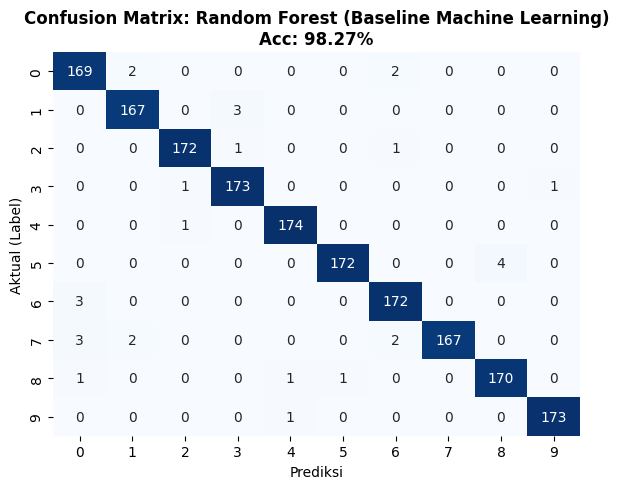

98.27487061529615

In [57]:
# 1. EVALUASI BASELINE (RANDOM FOREST)
# Random Forest butuh input 2D (Flattened), bukan 3D
X_test_flat = X_test.reshape(X_test.shape[0], -1)
y_pred_rf = rf_model.predict(X_test_flat)
evaluate_and_plot("Random Forest (Baseline Machine Learning)", y_test, y_pred_rf)

--- Evaluasi Convolutional Neural Network (Deep Learning) ---
✅ Akurasi Testing: 99.31%


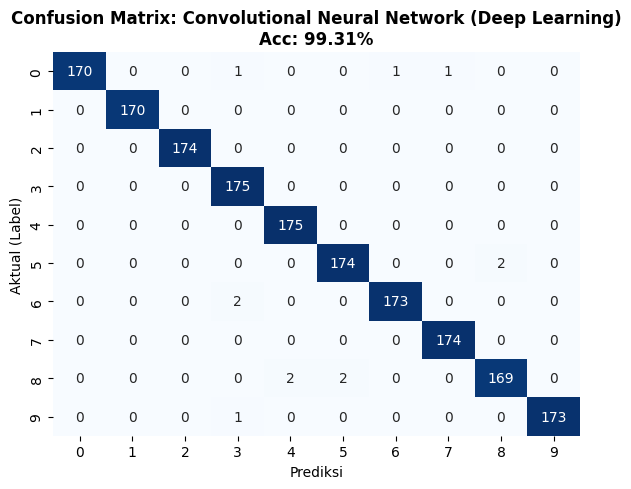

99.30994824611847

In [58]:
# 2. EVALUASI DEEP LEARNING (CNN)
# CNN butuh input Tensor
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
X_test_tensor = X_test_tensor.to('cuda')
model_cnn.eval()

with torch.no_grad(): # Hemat memori
    outputs = model_cnn(X_test_tensor)
    _, y_pred_cnn = torch.max(outputs, 1)

# Kembalikan ke CPU untuk visualisasi
y_pred_cnn = y_pred_cnn.cpu().numpy()
evaluate_and_plot("Convolutional Neural Network (Deep Learning)", y_test, y_pred_cnn)

--- Evaluasi ROCKET (Proposed Method) ---
✅ Akurasi Testing: 99.71%


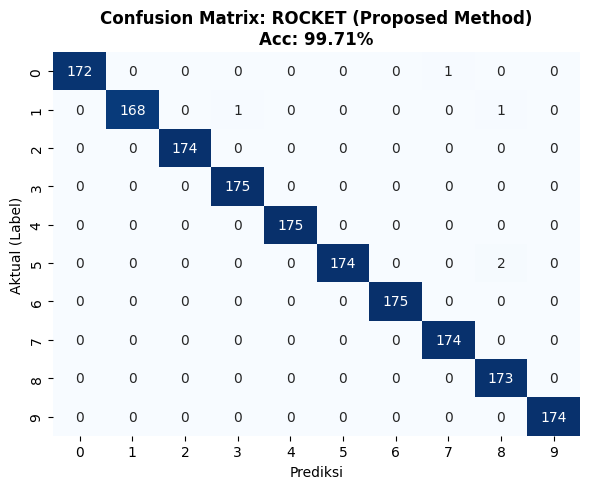

99.71247843588269

In [59]:
# 3. EVALUASI PROPOSED METHOD (ROCKET)
# ROCKET butuh fitur hasil transformasi, bukan raw data
X_test_rocket_transformed = minirocket.transform(X_test)
y_pred_rocket = classifier.predict(X_test_rocket_transformed)
evaluate_and_plot("ROCKET (Proposed Method)", y_test, y_pred_rocket)

In [63]:
# 4. REKAPITULASI HASIL (LEADERBOARD)
df_result = pd.DataFrame(list(final_scores.items()), columns=['Model', 'Test Accuracy'])
df_result = df_result.sort_values(by='Test Accuracy', ascending=False).reset_index(drop=True)

# Hitung selisih improvement
baseline_acc = final_scores['Random Forest (Baseline Machine Learning)']
df_result['Improvement vs Baseline'] = df_result['Test Accuracy'] - baseline_acc

print(df_result)

# Auto-Conclusion
winner = df_result.iloc[0]
print(f"\nTHE WINNER: {winner['Model']} ({winner['Test Accuracy']:.2f}%)")

                                          Model  Test Accuracy  \
0                      ROCKET (Proposed Method)      99.712478   
1  Convolutional Neural Network (Deep Learning)      99.309948   
2     Random Forest (Baseline Machine Learning)      98.274871   

   Improvement vs Baseline  
0                 1.437608  
1                 1.035078  
2                 0.000000  

THE WINNER: ROCKET (Proposed Method) (99.71%)


### 5. Evaluation

### 6. Deployment